# CallMeMaybe - Análisis de eficiencia de operadores

## Objetivo
Identificar operadores ineficaces basados en:
- Alta tasa de llamadas perdidas
- Tiempos de espera elevados
- Bajo volumen de llamadas atendidas



In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [16]:

data = pd.read_csv("Downloads/telecom_dataset_new.csv")
clients = pd.read_csv("Downloads/telecom_clients.csv")

data.head()


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [17]:
#agrupar por operador
operator_metrics = data.groupby("operator_id").agg({
    "is_missed_call": "sum",
    "calls_count": "sum",
    "total_call_duration": "sum"
}).reset_index()

operator_metrics.head()


,operator_id,is_missed_call,calls_count,total_call_duration
0,879896.0,50,1131,97427
1,879898.0,100,7974,391850
2,880020.0,7,54,2624
3,880022.0,33,219,22679
4,880026.0,94,2439,193666


In [18]:
#llamadas perdidas
operator_metrics["missed_call_rate"] = (
    operator_metrics["is_missed_call"] / operator_metrics["calls_count"]
)

operator_metrics.head()


,operator_id,is_missed_call,calls_count,total_call_duration,missed_call_rate
0,879896.0,50,1131,97427,0.044209
1,879898.0,100,7974,391850,0.012541
2,880020.0,7,54,2624,0.129630
3,880022.0,33,219,22679,0.150685
4,880026.0,94,2439,193666,0.038540


In [19]:
threshold = operator_metrics["missed_call_rate"].quantile(0.75)

threshold


np.float64(0.12128292268479185)

In [20]:
inefficient_operators = operator_metrics[
    operator_metrics["missed_call_rate"] > threshold
]

inefficient_operators


,operator_id,is_missed_call,calls_count,total_call_duration,missed_call_rate
2,880020.0,7,54,2624,0.129630
3,880022.0,33,219,22679,0.150685
6,880240.0,8,49,4436,0.163265
7,881278.0,7,20,543,0.350000
9,882478.0,1,4,151,0.250000
...,...,...,...,...,...
1080,970258.0,1,1,11,1.000000
1081,970484.0,2,7,117,0.285714
1082,970486.0,2,6,356,0.333333
1086,972408.0,2,8,275,0.250000


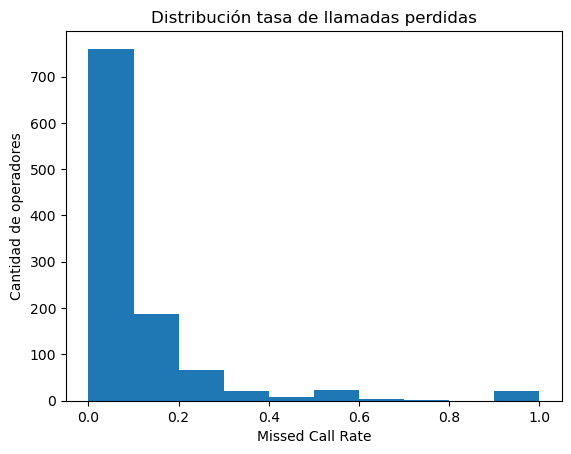

In [21]:


plt.hist(operator_metrics["missed_call_rate"])
plt.title("Distribución tasa de llamadas perdidas")
plt.xlabel("Missed Call Rate")
plt.ylabel("Cantidad de operadores")
plt.show()


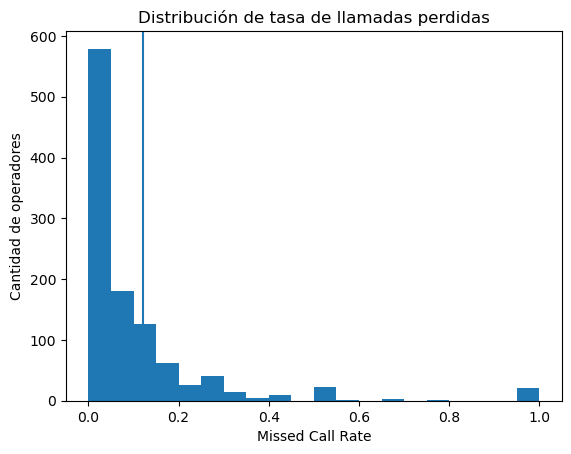

In [28]:
plt.hist(operator_metrics["missed_call_rate"], bins=20)

plt.axvline(threshold)
plt.title("Distribución de tasa de llamadas perdidas")
plt.xlabel("Missed Call Rate")
plt.ylabel("Cantidad de operadores")

plt.show()


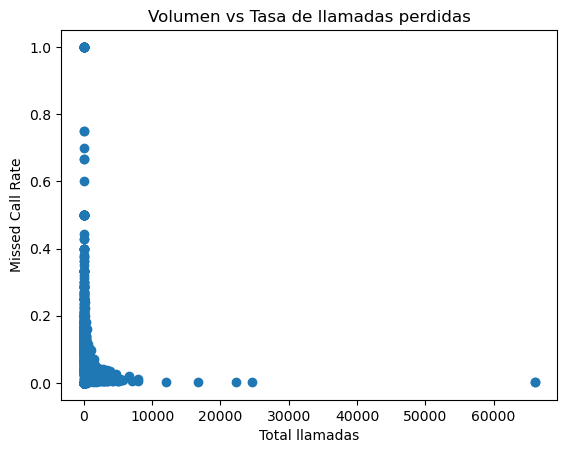

In [25]:
#Relación entre volumen de llamadas y tasa de perdidas
plt.scatter(operator_metrics["calls_count"],
            operator_metrics["missed_call_rate"])

plt.xlabel("Total llamadas")
plt.ylabel("Missed Call Rate")
plt.title("Volumen vs Tasa de llamadas perdidas")
plt.show()



In [26]:
#operadores eficaces e ineficaces
operator_metrics["is_inefficient"] = (
    operator_metrics["missed_call_rate"] > threshold
)


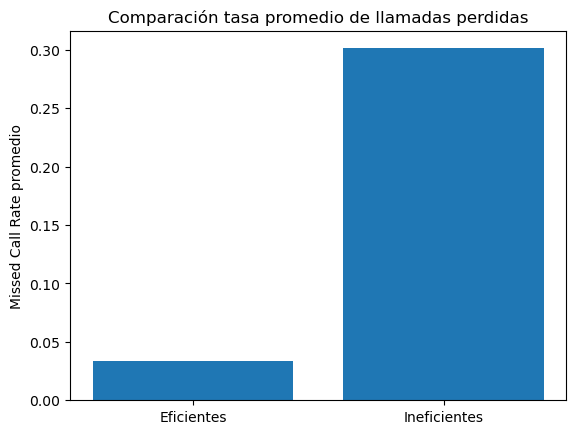

In [27]:
avg_rates = operator_metrics.groupby("is_inefficient")[
    "missed_call_rate"
].mean()

plt.bar(["Eficientes", "Ineficientes"], avg_rates)
plt.title("Comparación tasa promedio de llamadas perdidas")
plt.ylabel("Missed Call Rate promedio")
plt.show()


El análisis permitió identificar operadores con desempeño inferior mediante un criterio estadístico objetivo.
Las recomendaciones propuestas buscan mejorar la eficiencia operativa y optimizar la experiencia del cliente a través de intervenciones basadas en datos.

## Recomendaciones estratégicas ##
 1. Implementar seguimiento individual a operadores críticos

Se recomienda realizar un monitoreo específico a los operadores que superan el percentil 75 en tasa de llamadas perdidas.
Un seguimiento semanal permitiría identificar si el desempeño mejora tras intervenciones puntuales.

 2. Capacitación enfocada en gestión de llamadas

Los operadores con mayor tasa de llamadas perdidas podrían beneficiarse de capacitaciones en:

Manejo eficiente del tiempo

Priorización de llamadas entrantes

Uso adecuado de herramientas del sistema
 
 3. Revisar distribución de carga operativa

Es posible que algunos operadores estén gestionando un volumen desproporcionado de llamadas.
Se recomienda analizar la asignación de carga para asegurar una distribución equilibrada.

 4. Implementar métricas de monitoreo continuo

Se sugiere incorporar la tasa de llamadas perdidas como KPI mensual dentro del dashboard de supervisión.
Esto permitiría detectar desviaciones tempranas y actuar preventivamente.

5. Analizar relación entre duración de llamadas y eficiencia

Como siguiente paso, podría explorarse si una mayor duración promedio de llamadas está correlacionada con mayor tasa de llamadas perdidas.


